# Ancestral OR binding-repertoire analysis — internal nodes 1, 2, 3, 4, 5, 6, 12, 21, 32, 44

Reconstructed ancestral human olfactory-receptor sequences at internal nodes of the ASR
phylogeny, with a receptor–ligand model predicting which of 754 odorants each ancestral
node binds. This notebook characterises the predicted binding repertoires of ten
internal nodes: their phylogenetic relationships, shared vs. gained/lost ligands, the odor
qualities that are enriched (per node and along each edge), the chemistry of the bound
molecules, and the conserved sequence motifs that distinguish these nodes.

**Sections**
1. Data load & ligand→odor / chemistry mapping
2. Topology of the ten-node set (parents, MRCAs, induced subtree)
3. Per-node repertoires
4. Common ligands (strict intersection, pairwise intersection & Jaccard, UpSet)
5. Gains & losses (vs. immediate parent; all ordered pairs)
6. Odor-tag enrichment (permutation, two backgrounds; per node and per gain/loss set)
7. Chemistry of the ligand sets (RDKit descriptors & functional groups)
8. Sequence motifs as scaffold QC + pocket function-shift candidates (Class I vs II)

Binding calls use the binary median-prediction table; probabilities are loaded alongside
for reference. Node labels 1…44 map to `node_N` in the tree and `node_N_ASR` in the
prediction/FASTA files. All deliverables are written to `Results_july9/`.

In [1]:
import os, re, itertools, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
warnings.filterwarnings("ignore")

BASE = "/home/izirdeli/Documents.cglab/olfactory-receptors"
ASR  = f"{BASE}/Ancestral_Receptor_Reconstruciton/human_tree_asr_hagfish_outgroup"
PREDDIR = f"{BASE}/Downstream_Analysis/predictions/aggregated/ASR_Predictions"
RES  = f"{BASE}/Downstream_Analysis/notebooks/ancestral/Results_july9"
FIG  = f"{RES}/figures"; os.makedirs(FIG, exist_ok=True)

BIN_CSV  = f"{PREDDIR}/asr_median_prediction_wide.csv"
PROB_CSV = f"{PREDDIR}/asr_median_probability_wide.csv"
TREE     = f"{ASR}/PF13853_9606.7764.mafft.lg.treefile.rooted.withinternalnames"
ALN8     = f"{RES}/nodes10.mafft.fasta"

NODES  = [1, 2, 3, 4, 5, 6, 12, 21, 32, 44]           # internal-node labels of interest
NN     = len(NODES)
LAB    = {n: f"node_{n}" for n in NODES}              # tree label
ROW    = {n: f"node_{n}_ASR" for n in NODES}          # prediction/FASTA label
# validated CVD-safe categorical ramp (dataviz reference palette + 2 extra, fixed order; CVD ΔE>=21)
PAL    = ["#2a78d6","#1baf7a","#eda100","#008300","#4a3aa7","#e34948","#e87ba4","#eb6834","#0098c7","#9c4d00"]
NCOL   = {n: PAL[i] for i, n in enumerate(NODES)}
N_PERM, SEED = 99999, 20260709

plt.rcParams.update({"figure.dpi":110, "savefig.dpi":200, "font.size":10,
    "axes.spines.top":False, "axes.spines.right":False, "axes.grid":False,
    "axes.edgecolor":"#c3c2b7", "xtick.color":"#52514e", "ytick.color":"#52514e",
    "axes.labelcolor":"#0b0b0b", "text.color":"#0b0b0b"})
INK, MUT, GRID = "#0b0b0b", "#898781", "#e1e0d9"
def savefig(fig, name):
    for ext in ("png","svg"):
        fig.savefig(f"{FIG}/{name}.{ext}", bbox_inches="tight", facecolor="white")
    print("saved", name)
print("config OK — nodes:", NODES)

config OK — nodes: [1, 2, 3, 4, 5, 6, 12, 21, 32, 44]


## 1. Data load

Binary and probability prediction matrices (432 ancestral nodes × 754 ligands), the
ligand→odor tag map and RDKit descriptor cache (built in the `olfaction` env to avoid the
numpy/rdkit ABI clash). `bound[n]` is the set of ligands node *n* is predicted to bind.
The **full** binary matrix is kept because each node's immediate parent (needed for
gains/losses) may lie outside the ten-node set.

In [2]:
bin_df  = pd.read_csv(BIN_CSV,  index_col=0)
prob_df = pd.read_csv(PROB_CSV, index_col=0)
SML = [c for c in bin_df.columns if c.startswith("SML")]
bin_df = bin_df[SML].astype(int)
print("binary matrix:", bin_df.shape, "| ligands:", len(SML), "| ancestral nodes:", bin_df.shape[0])

# bound-ligand set for ANY ancestral node label (node_N_ASR)
def bound_of(label):
    if label not in bin_df.index: return None
    row = bin_df.loc[label]
    return set(row.index[row.values == 1])
bound = {n: bound_of(ROW[n]) for n in NODES}
for n in NODES: assert bound[n] is not None, f"missing predictions for {ROW[n]}"

# ligand -> odor tags
lig = pd.read_csv(f"{RES}/ligand_odor_map.csv")           # SML,SMILES,InChIKey,Odors
tag_long = pd.read_csv(f"{RES}/ligand_tag_long.csv")      # SML,tag
desc = pd.read_csv(f"{RES}/ligand_descriptors.csv").set_index("SML")
TAGS = sorted(tag_long.tag.unique())
print("ligands with >=1 odor tag:", lig.Odors.notna().sum(), "| unique tags:", len(TAGS))
print("descriptor cache:", desc.shape)
print("bound-set sizes:", {n: len(bound[n]) for n in NODES})

binary matrix: (432, 754) | ligands: 754 | ancestral nodes: 432
ligands with >=1 odor tag: 575 | unique tags: 147
descriptor cache: (754, 29)
bound-set sizes: {1: 177, 2: 130, 3: 113, 4: 138, 5: 147, 6: 130, 12: 77, 21: 60, 32: 67, 44: 51}


## 2. Topology of the ten-node set

Parsed from the rooted ASR tree (root `node_0`, hagfish outgroup). For the ten nodes we
report each node's immediate parent, the ancestor/descendant relationships *within* the
set, the pairwise MRCA matrix, and the **induced subtree** (the minimal topology
connecting the ten nodes through their MRCAs).

In [3]:
from Bio import Phylo
tree = Phylo.read(TREE, "newick")
name2clade = {c.name: c for c in tree.find_clades() if c.name}
# parent map + depth + ancestor-name sets over the whole tree
parent = {}
for cl in tree.find_clades():
    for ch in cl.clades:
        parent[ch.name if ch.name else id(ch)] = cl
depth, anc = {}, {}
for n in NODES:
    path = tree.get_path(name2clade[LAB[n]])          # root-exclusive .. target
    depth[n] = len(path)
    anc[n] = set([tree.root.name] + [c.name for c in path[:-1]])

# immediate parent label of each node (may be outside the set / the root)
par_lab = {}
for n in NODES:
    p = parent.get(LAB[n])
    par_lab[n] = p.name if (p is not None and p.name) else None

lab2node = {LAB[n]: n for n in NODES}
# within-set ancestor/descendant relationships
within_anc = {n: sorted([lab2node[a] for a in anc[n] if a in lab2node]) for n in NODES}
within_desc = {n: sorted([m for m in NODES if LAB[n] in anc[m]]) for n in NODES}

# pairwise MRCA
mrca = pd.DataFrame(index=NODES, columns=NODES, dtype=object)
for a in NODES:
    for b in NODES:
        m = tree.common_ancestor([name2clade[LAB[a]], name2clade[LAB[b]]])
        mrca.loc[a, b] = m.name
mrca.to_csv(f"{RES}/pairwise_mrca.csv")

topo = pd.DataFrame({
    "node": NODES,
    "tree_label": [LAB[n] for n in NODES],
    "immediate_parent": [par_lab[n] for n in NODES],
    "parent_has_predictions": [(par_lab[n]+"_ASR") in bin_df.index if par_lab[n] else False for n in NODES],
    "root_depth": [depth[n] for n in NODES],
    "ancestors_in_set": ["; ".join(map(str, within_anc[n])) or "-" for n in NODES],
    "descendants_in_set": ["; ".join(map(str, within_desc[n])) or "-" for n in NODES],
    "n_bound": [len(bound[n]) for n in NODES],
}).set_index("node")
topo.to_csv(f"{RES}/topology_summary.csv")
print("Immediate parents:")
for n in NODES:
    print(f"  node_{n:<2} depth {depth[n]:>2}  parent {par_lab[n]}"
          f"{'  (predicted)' if topo.loc[n,'parent_has_predictions'] else '  (no preds)'}")
topo

Immediate parents:
  node_1  depth  1  parent node_0  (no preds)
  node_2  depth  2  parent node_1  (predicted)
  node_3  depth  2  parent node_1  (predicted)
  node_4  depth  3  parent node_2  (predicted)
  node_5  depth  3  parent node_2  (predicted)
  node_6  depth  3  parent node_3  (predicted)
  node_12 depth  4  parent node_6  (predicted)
  node_21 depth  5  parent node_12  (predicted)
  node_32 depth  6  parent node_21  (predicted)
  node_44 depth  7  parent node_32  (predicted)


,tree_label,immediate_parent,parent_has_predictions,root_depth,ancestors_in_set,descendants_in_set,n_bound
node,,,,,,,
1,node_1,node_0,False,1,-,2; 3; 4; 5; 6; 12; 21; 32; 44,177
2,node_2,node_1,True,2,1,4; 5,130
3,node_3,node_1,True,2,1,6; 12; 21; 32; 44,113
4,node_4,node_2,True,3,1; 2,-,138
5,node_5,node_2,True,3,1; 2,-,147
6,node_6,node_3,True,3,1; 3,12; 21; 32; 44,130
12,node_12,node_6,True,4,1; 3; 6,21; 32; 44,77
21,node_21,node_12,True,5,1; 3; 6; 12,32; 44,60
32,node_32,node_21,True,6,1; 3; 6; 12; 21,44,67


Induced subtree ( * = node of interest ):
node_1 *  [bound 177]
   node_3 *  [bound 113]
      node_6 *  [bound 130]
         node_12 *  [bound 77]
            node_21 *  [bound 60]
               node_32 *  [bound 67]
                  node_44 *  [bound 51]
   node_2 *  [bound 130]
      node_4 *  [bound 138]
      node_5 *  [bound 147]


saved fig2_induced_subtree


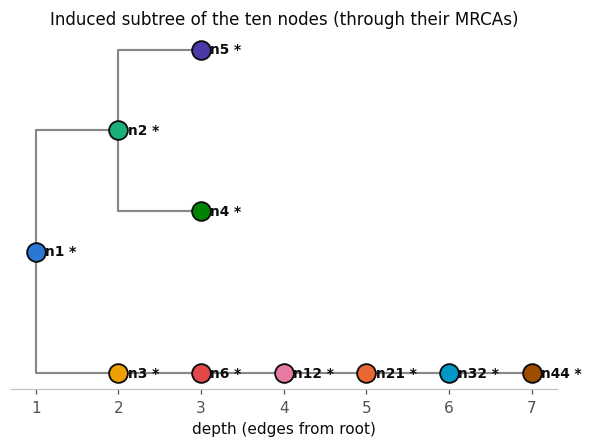

In [4]:
# ---- induced subtree over the 8 nodes + their pairwise MRCAs ----
mrca_names = set(mrca.values.ravel())
U = sorted(set(LAB[n] for n in NODES) | mrca_names,
           key=lambda nm: len(tree.get_path(name2clade[nm])))     # shallow -> deep
anc_name = {nm: set([tree.root.name] + [c.name for c in tree.get_path(name2clade[nm])[:-1]]) for nm in U}
dep_name = {nm: len(tree.get_path(name2clade[nm])) for nm in U}
# induced parent = deepest strict ancestor that is itself in U
ipar = {}
for nm in U:
    cand = [a for a in U if a in anc_name[nm]]
    ipar[nm] = max(cand, key=lambda a: dep_name[a]) if cand else None
children = {nm: [] for nm in U}
for nm in U:
    if ipar[nm] is not None: children[ipar[nm]].append(nm)
roots = [nm for nm in U if ipar[nm] is None]

def show(nm, ind=0):
    tag = " *" if nm in lab2node else ""              # * = a node of interest
    extra = f"  [bound {len(bound[lab2node[nm]])}]" if nm in lab2node else ""
    print("   " * ind + f"{nm}{tag}{extra}")
    for ch in sorted(children[nm], key=lambda c: dep_name[c]):
        show(ch, ind + 1)
print("Induced subtree ( * = node of interest ):")
for r in roots: show(r)
pd.DataFrame({"node": U, "induced_parent": [ipar[nm] for nm in U],
             "depth": [dep_name[nm] for nm in U],
             "is_target": [nm in lab2node for nm in U]}
            ).to_csv(f"{RES}/induced_subtree_edges.csv", index=False)

# small cladogram figure of the induced subtree
ys = {}; _c = itertools.count()
def layout(nm):
    ch = sorted(children[nm], key=lambda c: dep_name[c])
    if not ch: ys[nm] = next(_c); return ys[nm]
    yy = [layout(c) for c in ch]; ys[nm] = sum(yy) / len(yy); return ys[nm]
for r in roots: layout(r)
fig, ax = plt.subplots(figsize=(6.4, 4.2))
for nm in U:
    if ipar[nm] is not None:
        x0, x1, y0, y1 = dep_name[ipar[nm]], dep_name[nm], ys[ipar[nm]], ys[nm]
        ax.plot([x0, x0, x1], [y0, y1, y1], color="#898781", lw=1.4, zorder=1)
for nm in U:
    t = nm in lab2node
    ax.scatter([dep_name[nm]], [ys[nm]], s=150 if t else 45,
               color=NCOL[lab2node[nm]] if t else "#ffffff",
               edgecolor=INK if t else "#898781", zorder=3, lw=1.2)
    ax.annotate(nm.replace("node_","n") + (" *" if t else ""),
                (dep_name[nm], ys[nm]), xytext=(6, 0), textcoords="offset points",
                va="center", fontsize=9, fontweight="bold" if t else "normal",
                color=INK if t else MUT)
ax.set_xlabel("depth (edges from root)"); ax.set_yticks([])
ax.set_title("Induced subtree of the ten nodes (through their MRCAs)", fontsize=11)
ax.spines["left"].set_visible(False)
savefig(fig, "fig2_induced_subtree"); plt.show()

### 2b. OR class (I / II) of each node

Each ancestral node is assigned to an OR class from the classes of its descendant human
leaves (`human433_OR_classes.csv`). This orients the node set relative to the deepest,
most functionally consequential division of the vertebrate OR repertoire — the Class I
("fish-like", more ancient, tuned to water-soluble / acidic odorants) vs. Class II
("mammalian", airborne-odorant) split [Niimura & Nei, *PNAS* 2003; Nei, Niimura & Nozawa,
*Nat. Rev. Genet.* 2008; Freitag et al., *J. Comp. Physiol. A* 1998].

  node_1 : mixed(class I/II split) (433 leaves, 14% Class I)
  node_2 : Class_I                ( 62 leaves, 100% Class I)
  node_3 : Class_II               (371 leaves, 0% Class I)
  node_4 : Class_I                ( 55 leaves, 100% Class I)
  node_5 : Class_I                (  7 leaves, 100% Class I)
  node_6 : Class_II               (370 leaves, 0% Class I)
  node_12: Class_II               (365 leaves, 0% Class I)
  node_21: Class_II               (337 leaves, 0% Class I)
  node_32: Class_II               (328 leaves, 0% Class I)
  node_44: Class_II               ( 50 leaves, 0% Class I)
Class I nodes: [2, 4, 5] | Class II nodes: [3, 6, 12, 21, 32, 44]


saved fig2b_node_or_class


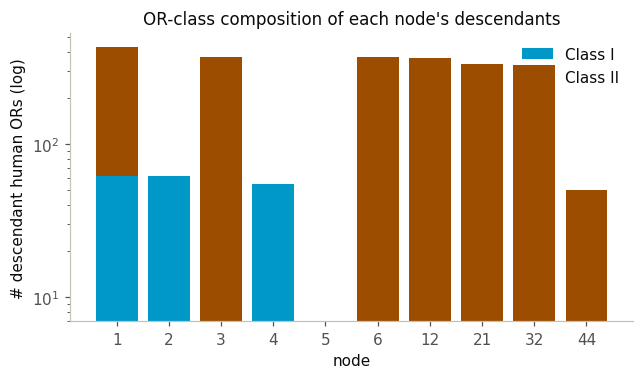

In [5]:
cldf = pd.read_csv(f"{BASE}/Phylogenetic_Analysis/data/HumanTree/human433_OR_classes.csv")
leaf2class = dict(zip(cldf.leaf_id, cldf.OR_class))
node_class, class_frac, n_desc = {}, {}, {}
for n in NODES:
    leaves = [t.name for t in name2clade[LAB[n]].get_terminals()]
    cc = [leaf2class[l] for l in leaves if l in leaf2class]
    ci = cc.count("Class_I"); tot = len(cc)
    class_frac[n] = ci / tot if tot else float("nan"); n_desc[n] = tot
    node_class[n] = ("Class_I" if class_frac[n] >= 0.9 else
                     "Class_II" if class_frac[n] <= 0.1 else "mixed(class I/II split)")
CLASS_I_NODES  = [n for n in NODES if node_class[n] == "Class_I"]
CLASS_II_NODES = [n for n in NODES if node_class[n] == "Class_II"]
topo["OR_class"] = [node_class[n] for n in NODES]
topo["n_descendant_leaves"] = [n_desc[n] for n in NODES]
topo["frac_class_I_descendants"] = [round(class_frac[n], 3) for n in NODES]
topo.to_csv(f"{RES}/topology_summary.csv")
for n in NODES:
    print(f"  node_{n:<2}: {node_class[n]:<22} ({n_desc[n]:>3} leaves, {class_frac[n]:.0%} Class I)")
print("Class I nodes:", CLASS_I_NODES, "| Class II nodes:", CLASS_II_NODES)

# figure: descendant-leaf class composition per node
fig, ax = plt.subplots(figsize=(6.6, 3.4))
ci = [class_frac[n]*n_desc[n] for n in NODES]; cii = [(1-class_frac[n])*n_desc[n] for n in NODES]
x = np.arange(NN)
ax.bar(x, ci,  color="#0098c7", label="Class I")
ax.bar(x, cii, bottom=ci, color="#9c4d00", label="Class II")
ax.set_yscale("log"); ax.set_ylabel("# descendant human ORs (log)")
ax.set_xticks(x); ax.set_xticklabels(NODES); ax.set_xlabel("node")
ax.legend(frameon=False); ax.set_title("OR-class composition of each node's descendants", fontsize=11)
savefig(fig, "fig2b_node_or_class"); plt.show()

## 3. Per-node repertoires

Number of bound ligands per node and the full ligand set (written to
`repertoires_per_node.csv`, one column per node).

saved fig3_repertoire_sizes


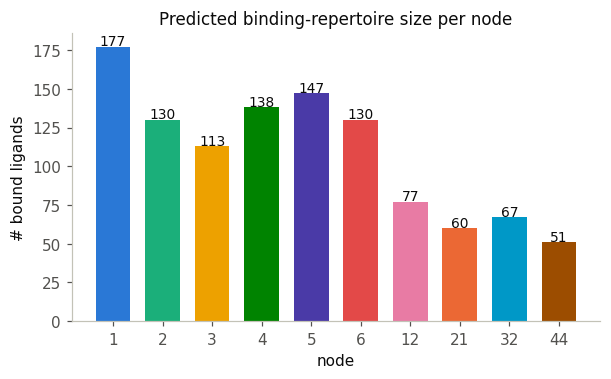

,n_bound,frac_of_pool
node,,
1,177,0.235
2,130,0.172
3,113,0.150
4,138,0.183
5,147,0.195
6,130,0.172
12,77,0.102
21,60,0.080
32,67,0.089


In [6]:
rep_rows = []
maxlen = max(len(bound[n]) for n in NODES)
rep_wide = {}
for n in NODES:
    s = sorted(bound[n])
    rep_wide[f"node_{n}"] = s + [""] * (maxlen - len(s))
    rep_rows.append({"node": n, "n_bound": len(s),
                     "frac_of_pool": round(len(s) / len(SML), 3)})
pd.DataFrame(rep_wide).to_csv(f"{RES}/repertoires_per_node.csv", index=False)
rep_summary = pd.DataFrame(rep_rows).set_index("node")

fig, ax = plt.subplots(figsize=(6.2, 3.4))
ax.bar([str(n) for n in NODES], [len(bound[n]) for n in NODES],
       color=[NCOL[n] for n in NODES], width=0.7)
for i, n in enumerate(NODES):
    ax.text(i, len(bound[n]) + 1, str(len(bound[n])), ha="center", fontsize=9, color=INK)
ax.set_ylabel("# bound ligands"); ax.set_xlabel("node")
ax.set_title("Predicted binding-repertoire size per node", fontsize=11)
savefig(fig, "fig3_repertoire_sizes"); plt.show()
rep_summary

## 4. Common ligands & overlap structure

Strict intersection (bound by all ten), pairwise intersection-size and Jaccard matrices,
and an UpSet plot of the intersection structure over the ten sets.

Ligands bound by ALL ten nodes: 14


saved fig4_overlap_matrices


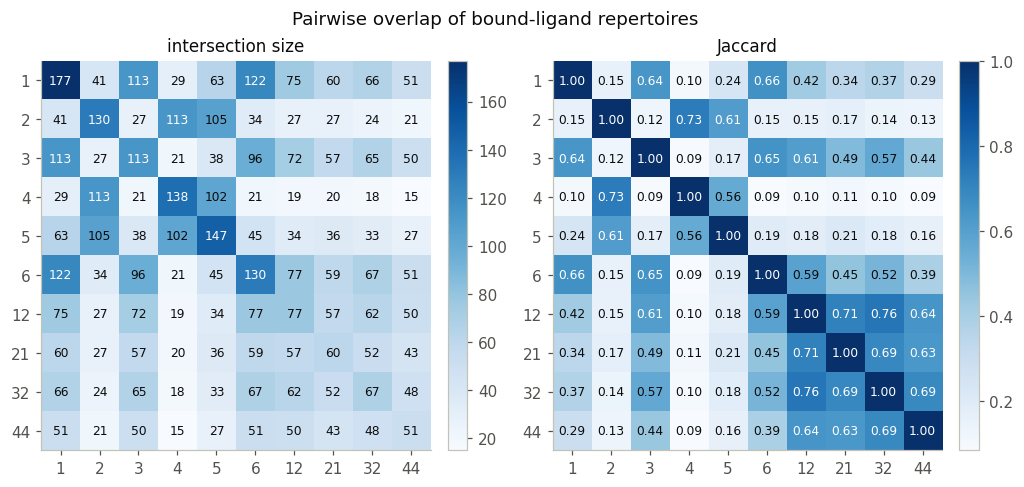

strict intersection ligands (first rows):


,SML,SMILES,Odors
89,SML0089,C[C@]12CC[C@H]3[C@H]([C@@H]1CC=C2)CC[C@@H]4[C@...,NaN
100,SML0100,CC(=O)OC1=C(C=C(C=C1)CC=C)OC,"clove, spicy, balsamic, sweet, floral, malty, ..."
110,SML0110,C/C=C/C1=CC(=C(C=C1)O)OC,"spicy, phenolic, sweet, floral"
120,SML0120,CC1COCC2=CC3=C(C=C12)C(C(C3(C)C)C)(C)C,"sweet, floral, musk"
135,SML0135,C[C@@H]1CC(=O)C=C2[C@]1(C[C@@H](CC2)C(=C)C)C,"citrus, sweet, grapefruit, woody, orange"
478,SML0478,C[C@@H]1CC[C@@H]2[C@]13CC[C@@]([C@H](C3)C2(C)C...,NaN
537,SML0537,CC1CCC2C13CCC(C(C3)C2(C)C)(C)OC(=O)C,NaN
609,SML0609,C[C@]12CC[C@H]3[C@H]([C@@H]1CCC2=O)CCC4=CC(=O)...,NaN
610,SML0610,C[C@]12CCC(=O)C[C@@H]1CC[C@@H]3[C@@H]2CC[C@]4(...,NaN
622,SML0622,C[C@]12CC[C@H]3[C@H]([C@@H]1CC[C@H]2O)CCC4=CC(...,NaN


In [7]:
common_all = set.intersection(*[bound[n] for n in NODES])
print("Ligands bound by ALL ten nodes:", len(common_all))
common_tab = lig[lig.SML.isin(common_all)][["SML","SMILES","Odors"]].sort_values("SML")
common_tab.to_csv(f"{RES}/strict_intersection_ligands.csv", index=False)

inter = pd.DataFrame(index=NODES, columns=NODES, dtype=int)
jac   = pd.DataFrame(index=NODES, columns=NODES, dtype=float)
for a in NODES:
    for b in NODES:
        i = len(bound[a] & bound[b]); u = len(bound[a] | bound[b])
        inter.loc[a, b] = i; jac.loc[a, b] = i / u if u else 0.0
inter.to_csv(f"{RES}/pairwise_intersection_size.csv")
jac.astype(float).round(4).to_csv(f"{RES}/pairwise_jaccard.csv")

fig, axes = plt.subplots(1, 2, figsize=(11, 4.6))
for ax, M, ttl, cm, fmt in [(axes[0], inter.astype(int), "intersection size", "Blues", "d"),
                            (axes[1], jac.astype(float), "Jaccard", "Blues", ".2f")]:
    im = ax.imshow(M.values.astype(float), cmap=cm)
    ax.set_xticks(range(NN)); ax.set_yticks(range(NN))
    ax.set_xticklabels(NODES); ax.set_yticklabels(NODES)
    ax.set_title(ttl, fontsize=11)
    thr = M.values.astype(float).max() * 0.6
    for i in range(NN):
        for j in range(NN):
            v = M.values[i, j]
            ax.text(j, i, format(v, fmt), ha="center", va="center", fontsize=8,
                    color="white" if v > thr else INK)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.suptitle("Pairwise overlap of bound-ligand repertoires", fontsize=12)
savefig(fig, "fig4_overlap_matrices"); plt.show()
print("strict intersection ligands (first rows):"); common_tab.head(12)

saved fig5_upset


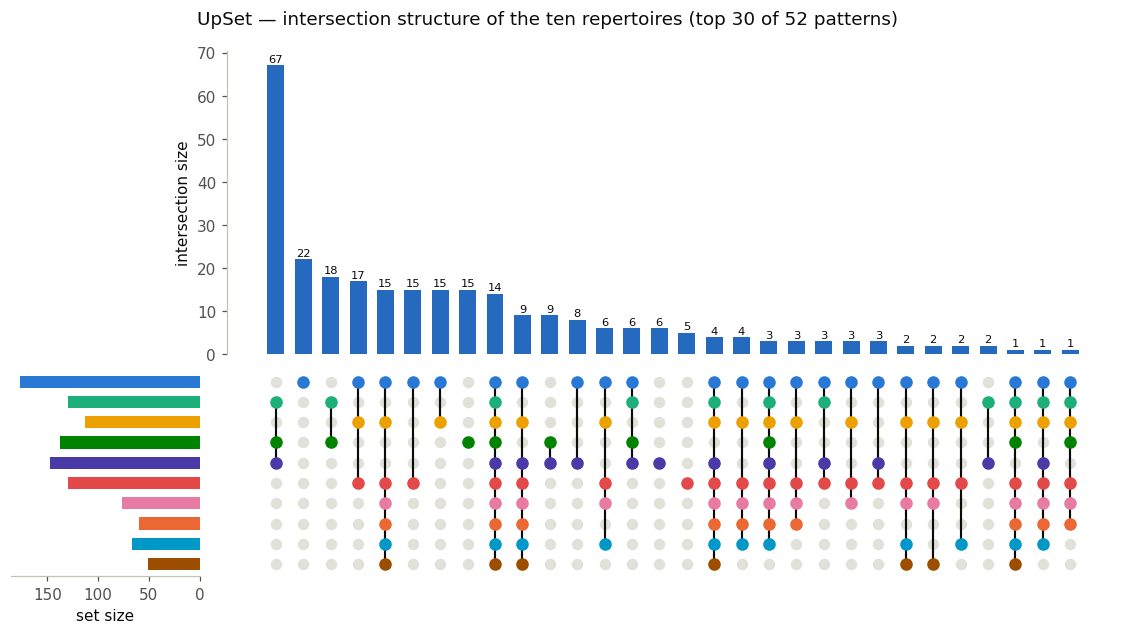

In [8]:
# ---- UpSet plot (matplotlib) over the 8 sets ----
universe = sorted(set().union(*[bound[n] for n in NODES]))
sig = {}                                              # membership signature -> ligand count
member = {l: tuple(l in bound[n] for n in NODES) for l in universe}
for l in universe:
    sig[member[l]] = sig.get(member[l], 0) + 1
combos = sorted(sig.items(), key=lambda kv: (-kv[1], -sum(kv[0])))
TOPC = min(30, len(combos))
combos = combos[:TOPC]

fig = plt.figure(figsize=(min(13, 4 + 0.42 * TOPC), 6.2))
gs = fig.add_gridspec(2, 2, width_ratios=[1.1, 5.2], height_ratios=[2.2, 1.5],
                      wspace=0.05, hspace=0.06)
axb = fig.add_subplot(gs[0, 1])                       # top: intersection-size bars
axm = fig.add_subplot(gs[1, 1], sharex=axb)           # bottom: membership matrix
axs = fig.add_subplot(gs[1, 0], sharey=axm)           # left: set-size bars
xs = np.arange(TOPC)
axb.bar(xs, [c[1] for c in combos], color="#256abf", width=0.62)
for x, (_, c) in zip(xs, combos):
    axb.text(x, c + 0.3, str(c), ha="center", va="bottom", fontsize=7.5, color=INK)
axb.set_ylabel("intersection size"); axb.tick_params(labelbottom=False)
axb.spines["bottom"].set_visible(False)
# matrix
for yi, n in enumerate(NODES):
    axm.scatter(xs, [yi]*TOPC, s=42, color="#e1e0d9", zorder=1)
    on = [x for x, (m, _) in zip(xs, combos) if m[yi]]
    axm.scatter(on, [yi]*len(on), s=52, color=NCOL[n], zorder=3)
for x, (m, _) in zip(xs, combos):
    idx = [yi for yi in range(NN) if m[yi]]
    if len(idx) > 1: axm.plot([x, x], [min(idx), max(idx)], color=INK, lw=1.4, zorder=2)
axm.set_yticks(range(NN)); axm.set_yticklabels([f"node_{n}" for n in NODES])
axm.set_xticks([]); axm.set_ylim(-0.6, NN-0.4); axm.invert_yaxis()
for sp in ("top","right","bottom","left"): axm.spines[sp].set_visible(False)
# left set-size bars
sizes = [len(bound[n]) for n in NODES]
axs.barh(range(NN), sizes, color=[NCOL[n] for n in NODES], height=0.6)
axs.invert_xaxis(); axs.set_yticks([]); axs.set_xlabel("set size")
for sp in ("top","right","left"): axs.spines[sp].set_visible(False)
fig.suptitle(f"UpSet — intersection structure of the ten repertoires (top {TOPC} of {len(sig)} patterns)",
             fontsize=12, y=0.94)
savefig(fig, "fig5_upset"); plt.show()
pd.DataFrame([{**{f"node_{NODES[i]}": int(m[i]) for i in range(NN)}, "n_ligands": c}
             for m, c in combos]).to_csv(f"{RES}/upset_intersections.csv", index=False)

## 5. Gains & losses

**Edge (vs. parent):** for each node whose immediate parent has predictions,
gain = bound by child but not parent; loss = bound by parent but not child.
**All ordered pairs:** the raw directional difference sets (A-only, B-only, shared) for
every ordered pair among the ten, so gains/losses can be read along any chosen path.

saved fig6_gain_loss


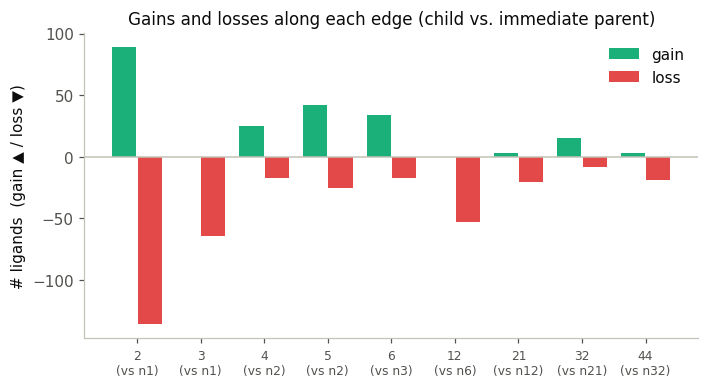

,parent,n_parent_bound,n_child_bound,n_gain,n_loss,n_retained
node,,,,,,
1,node_0,NaN,177,NaN,NaN,NaN
2,node_1,177.0,130,89.0,136.0,41.0
3,node_1,177.0,113,0.0,64.0,113.0
4,node_2,130.0,138,25.0,17.0,113.0
5,node_2,130.0,147,42.0,25.0,105.0
6,node_3,113.0,130,34.0,17.0,96.0
12,node_6,130.0,77,0.0,53.0,77.0
21,node_12,77.0,60,3.0,20.0,57.0
32,node_21,60.0,67,15.0,8.0,52.0


In [9]:
edge_rows, gain_sets, loss_sets = [], {}, {}
for n in NODES:
    p = par_lab[n]
    prow = (p + "_ASR") if p else None
    if prow and prow in bin_df.index:
        pb = set(bin_df.columns[bin_df.loc[prow].values == 1])
        g, l = bound[n] - pb, pb - bound[n]
        gain_sets[n], loss_sets[n] = g, l
        edge_rows.append({"node": n, "parent": p, "n_parent_bound": len(pb),
                          "n_child_bound": len(bound[n]), "n_gain": len(g), "n_loss": len(l),
                          "n_retained": len(bound[n] & pb)})
    else:
        edge_rows.append({"node": n, "parent": p, "n_parent_bound": np.nan,
                          "n_child_bound": len(bound[n]), "n_gain": np.nan,
                          "n_loss": np.nan, "n_retained": np.nan})
edge = pd.DataFrame(edge_rows).set_index("node")
edge.to_csv(f"{RES}/edge_gain_loss_summary.csv")
# full gain/loss ligand membership (long)
gl_long = []
for n in gain_sets:
    for s in sorted(gain_sets[n]): gl_long.append({"node": n, "kind": "gain", "SML": s})
    for s in sorted(loss_sets[n]): gl_long.append({"node": n, "kind": "loss", "SML": s})
gl_df = pd.DataFrame(gl_long, columns=["node","kind","SML"])
gl_df.merge(lig[["SML","Odors"]], on="SML", how="left"
    ).to_csv(f"{RES}/edge_gain_loss_ligands.csv", index=False)

# gain/loss vs parent figure
fig, ax = plt.subplots(figsize=(7.2, 3.6))
sub = edge.dropna(subset=["n_gain"])
x = np.arange(len(sub))
ax.bar(x - 0.2, sub.n_gain, width=0.38, color="#1baf7a", label="gain")
ax.bar(x + 0.2, -sub.n_loss, width=0.38, color="#e34948", label="loss")
ax.axhline(0, color="#c3c2b7", lw=1)
ax.set_xticks(x); ax.set_xticklabels([f"{i}\n(vs {sub.loc[i,'parent'].replace('node_','n')})" for i in sub.index], fontsize=8)
ax.set_ylabel("# ligands  (gain ▲ / loss ▼)"); ax.legend(frameon=False)
ax.set_title("Gains and losses along each edge (child vs. immediate parent)", fontsize=11)
savefig(fig, "fig6_gain_loss"); plt.show()
edge

In [10]:
# ---- all ordered-pair directional differences ----
pair_rows = []
for a, b in itertools.permutations(NODES, 2):
    ao, bo, sh = bound[a] - bound[b], bound[b] - bound[a], bound[a] & bound[b]
    pair_rows.append({"A": a, "B": b, "A_only": len(ao), "B_only": len(bo),
                      "shared": len(sh), "jaccard": round(len(sh)/len(bound[a]|bound[b]), 4)})
pairs = pd.DataFrame(pair_rows)
pairs.to_csv(f"{RES}/ordered_pair_differences.csv", index=False)
# also dump the actual A-only ligand lists for every ordered pair (long form)
aonly_long = []
for a, b in itertools.permutations(NODES, 2):
    for s in sorted(bound[a] - bound[b]):
        aonly_long.append({"A": a, "B": b, "SML": s})
pd.DataFrame(aonly_long).to_csv(f"{RES}/ordered_pair_A_only_ligands.csv", index=False)
print("ordered pairs:", len(pairs), "| A-only membership rows:", len(aonly_long))
pairs.head(10)

ordered pairs: 90 | A-only membership rows: 5144


,A,B,A_only,B_only,shared,jaccard
0,1,2,136,89,41,0.1541
1,1,3,64,0,113,0.6384
2,1,4,148,109,29,0.1014
3,1,5,114,84,63,0.2414
4,1,6,55,8,122,0.6595
5,1,12,102,2,75,0.4190
6,1,21,117,0,60,0.3390
7,1,32,111,1,66,0.3708
8,1,44,126,0,51,0.2881
9,2,1,89,136,41,0.1541


## 6. Odor-tag enrichment (permutation)

Right-tailed permutation test, **99,999** label shuffles, preserving each set's bound-set
size. For every (tag, set): observed count vs. the permutation distribution of counts in a
random same-size draw from the background. Reported: `Obs`, `Total` (background ligands
carrying the tag), `Exp` = size·Total/N, `Obs/Exp`, and right-tailed `p`
(min resolvable = 1e-05). **Enriched = p ≤ 0.01 and Obs/Exp > 1.**

Two backgrounds, run separately and labelled:
- **pool** — the full 754-ligand pool (what a node binds vs. all odorants).
- **union10** — the union of ligands bound by any of the ten nodes (what is *distinctive
  within this node set*).

Run per node, and on every gain and loss set (the neofunctionalization signal).

In [11]:
def build_tagmat(bg, tag_long):
    bg = list(bg); pos = {s: i for i, s in enumerate(bg)}
    tl = tag_long[tag_long.SML.isin(pos)]
    tags = sorted(tl.tag.unique())
    ti = {t: j for j, t in enumerate(tags)}
    B = np.zeros((len(bg), len(tags)), np.int16)
    for s, t in tl.itertuples(index=False): B[pos[s], ti[t]] = 1
    return bg, pos, tags, B

def enrich(sets, bg, tag_long, bg_name, n_perm=N_PERM, seed=SEED):
    bgl, pos, tags, B = build_tagmat(bg, tag_long)
    N = len(bgl); total = B.sum(0)
    names = list(sets)
    size = {s: len(sets[s]) for s in names}
    obs = {}
    for s in names:
        idx = [pos[x] for x in sets[s] if x in pos]
        obs[s] = B[idx].sum(0) if idx else np.zeros(len(tags), int)
    ge = {s: np.zeros(len(tags), np.int64) for s in names}
    rng = np.random.default_rng(seed)
    for _ in range(n_perm):
        cum = B[rng.permutation(N)].cumsum(0)
        for s in names:
            k = size[s]
            if 1 <= k <= N: ge[s] += (cum[k-1] >= obs[s])
    rows = []
    for s in names:
        k = size[s]
        p = (1 + ge[s]) / (n_perm + 1)
        exp = k * total / N
        for j, t in enumerate(tags):
            if obs[s][j] == 0: continue                # a tag can only be enriched if present
            rows.append({"set": s, "background": bg_name, "tag": t,
                         "Obs": int(obs[s][j]), "Total": int(total[j]), "set_size": k,
                         "Exp": round(float(exp[j]), 3),
                         "Obs_over_Exp": round(float(obs[s][j] / exp[j]) if exp[j] else np.nan, 3),
                         "p": float(p[j])})
    df = pd.DataFrame(rows)
    df["enriched"] = (df.p <= 0.01) & (df.Obs_over_Exp > 1)
    return df.sort_values(["set", "p", "Obs_over_Exp"], ascending=[True, True, False])

POOL   = list(SML)
UNION8 = sorted(set().union(*[bound[n] for n in NODES]))
node_sets = {f"node_{n}": bound[n] for n in NODES}
print(f"backgrounds: pool={len(POOL)}  union10={len(UNION8)}  | running {N_PERM} permutations x several set groups ...")
enr_node_pool   = enrich(node_sets, POOL,   tag_long, "pool")
enr_node_union  = enrich(node_sets, UNION8, tag_long, "union10")
enr_node = pd.concat([enr_node_pool, enr_node_union], ignore_index=True)
enr_node.to_csv(f"{RES}/enrichment_per_node.csv", index=False)
print("per-node enrichment rows:", len(enr_node),
      "| enriched (pool):", enr_node_pool.enriched.sum(),
      "| enriched (union10):", enr_node_union.enriched.sum())
enr_node[enr_node.enriched].groupby(["background","set"]).size()

backgrounds: pool=754  union10=303  | running 99999 permutations x several set groups ...


per-node enrichment rows: 2058 | enriched (pool): 40 | enriched (union10): 40


background  set    
pool        node_1     5
            node_2     7
            node_21    3
            node_3     1
            node_32    2
            node_4     8
            node_44    3
            node_5     8
            node_6     3
union10     node_1     5
            node_12    3
            node_2     4
            node_21    2
            node_3     2
            node_32    2
            node_4     8
            node_44    3
            node_5     5
            node_6     6
dtype: int64

In [12]:
# enrichment on gain / loss sets (both backgrounds)
gain_named = {f"node_{n}_gain": gain_sets[n] for n in gain_sets if len(gain_sets[n]) > 0}
loss_named = {f"node_{n}_loss": loss_sets[n] for n in loss_sets if len(loss_sets[n]) > 0}
frames = []
for nm, S in [("pool", POOL), ("union10", UNION8)]:
    if gain_named: frames.append(enrich(gain_named, S, tag_long, nm))
    if loss_named: frames.append(enrich(loss_named, S, tag_long, nm))
enr_edge = pd.concat(frames, ignore_index=True) if frames else pd.DataFrame()
enr_edge.to_csv(f"{RES}/enrichment_gain_loss.csv", index=False)
if len(enr_edge):
    print("gain/loss enrichment rows:", len(enr_edge),
          "| enriched:", int(enr_edge.enriched.sum()))
    display(enr_edge[enr_edge.enriched].sort_values(["set","p"])[
        ["set","background","tag","Obs","Total","Exp","Obs_over_Exp","p"]].head(40))

gain/loss enrichment rows: 1892 | enriched: 115


,set,background,tag,Obs,Total,Exp,Obs_over_Exp,p
368,node_12_loss,pool,balsamic,12,38,2.671,4.493,0.00001
1314,node_12_loss,union10,balsamic,12,23,4.023,2.983,0.00008
369,node_12_loss,pool,hyacinth,4,7,0.492,8.129,0.00068
1315,node_12_loss,union10,hyacinth,4,4,0.700,5.717,0.00104
1316,node_12_loss,union10,potato,4,5,0.875,4.574,0.00360
1317,node_12_loss,union10,hazelnut,3,3,0.525,5.717,0.00522
1318,node_12_loss,union10,nutty,8,18,3.149,2.541,0.00584
1401,node_21_loss,union10,sulfurous,5,13,0.858,5.827,0.00061
1402,node_21_loss,union10,burnt,4,10,0.660,6.060,0.00232
455,node_21_loss,pool,burnt,4,23,0.610,6.557,0.00237


saved fig7_enrichment_per_node_union10


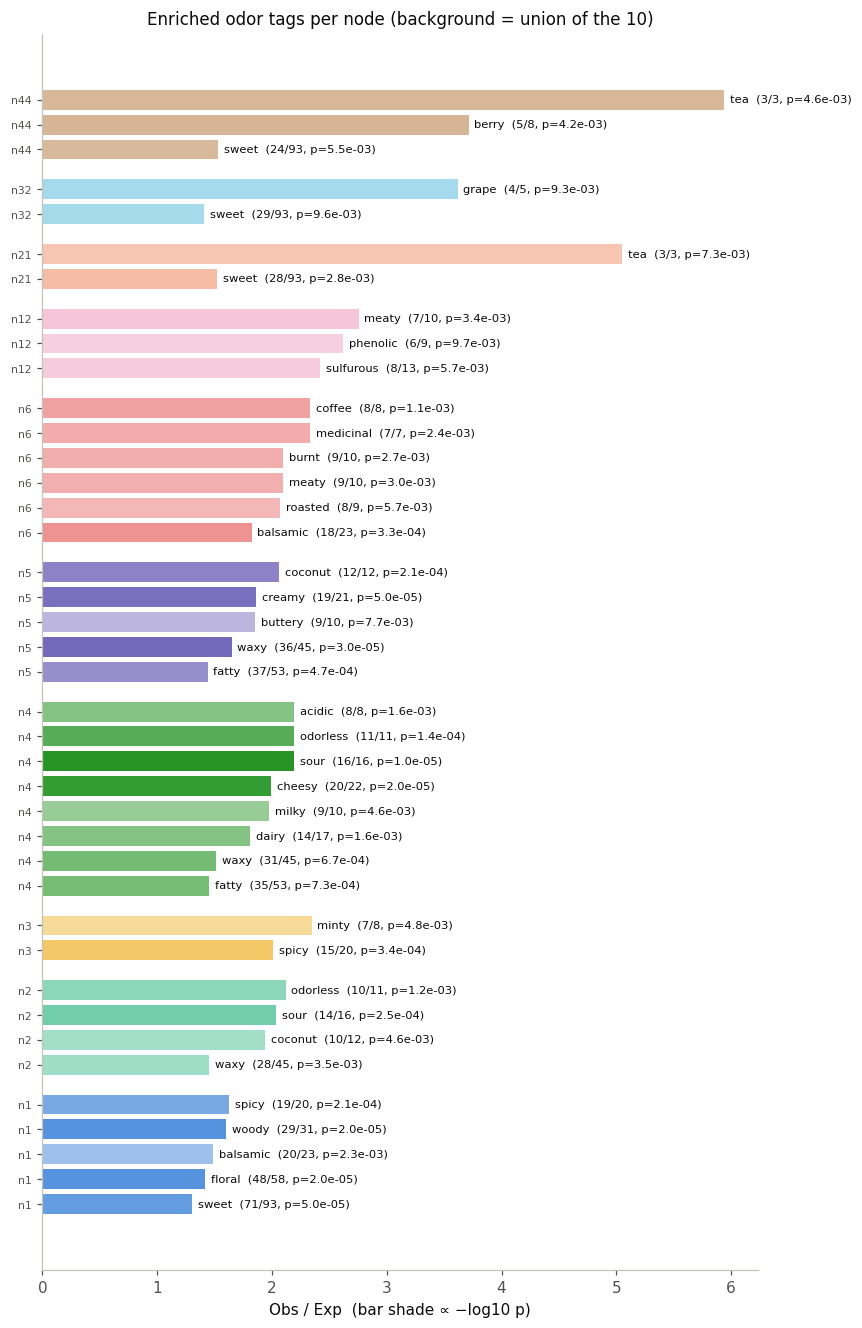

In [13]:
# enrichment figure: enriched tags per node (union10 background = distinctiveness)
sub = enr_node[(enr_node.background == "union10") & (enr_node.enriched)].copy()
order = [f"node_{n}" for n in NODES if f"node_{n}" in sub.set.values]
fig, ax = plt.subplots(figsize=(8.4, max(3.2, 0.34 * len(sub) + 1)))
y = 0; yticks, ylabels = [], []
import matplotlib as mpl
norm = mpl.colors.Normalize(2, 5)                      # -log10 p (min p 1e-5 -> 5)
for st in order:
    d = sub[sub.set == st].sort_values("Obs_over_Exp")
    col = NCOL[int(st.split("_")[1])]
    for _, r in d.iterrows():
        ax.barh(y, r.Obs_over_Exp, color=col, alpha=0.35 + 0.5 * norm(-np.log10(r.p)))
        ax.text(r.Obs_over_Exp + 0.05, y, f"{r.tag}  ({r.Obs}/{r.Total}, p={r.p:.1e})",
                va="center", fontsize=7.5, color=INK)
        yticks.append(y); ylabels.append(st.replace("node_","n")); y += 1
    y += 0.6
ax.set_yticks(yticks); ax.set_yticklabels(ylabels, fontsize=7)
ax.set_xlabel("Obs / Exp  (bar shade ∝ −log10 p)")
ax.set_title("Enriched odor tags per node (background = union of the 10)", fontsize=11)
ax.set_xlim(0, None)
savefig(fig, "fig7_enrichment_per_node_union10"); plt.show()

## 7. Chemistry of the ligand sets (RDKit)

Physicochemical descriptors and functional-group prevalence for each node's repertoire and
for the gain/loss sets, computed from cached RDKit descriptors. Node/edge medians are
compared to the full-pool baseline; functional-group prevalence is shown as a heatmap.

saved fig8_chem_boxplots


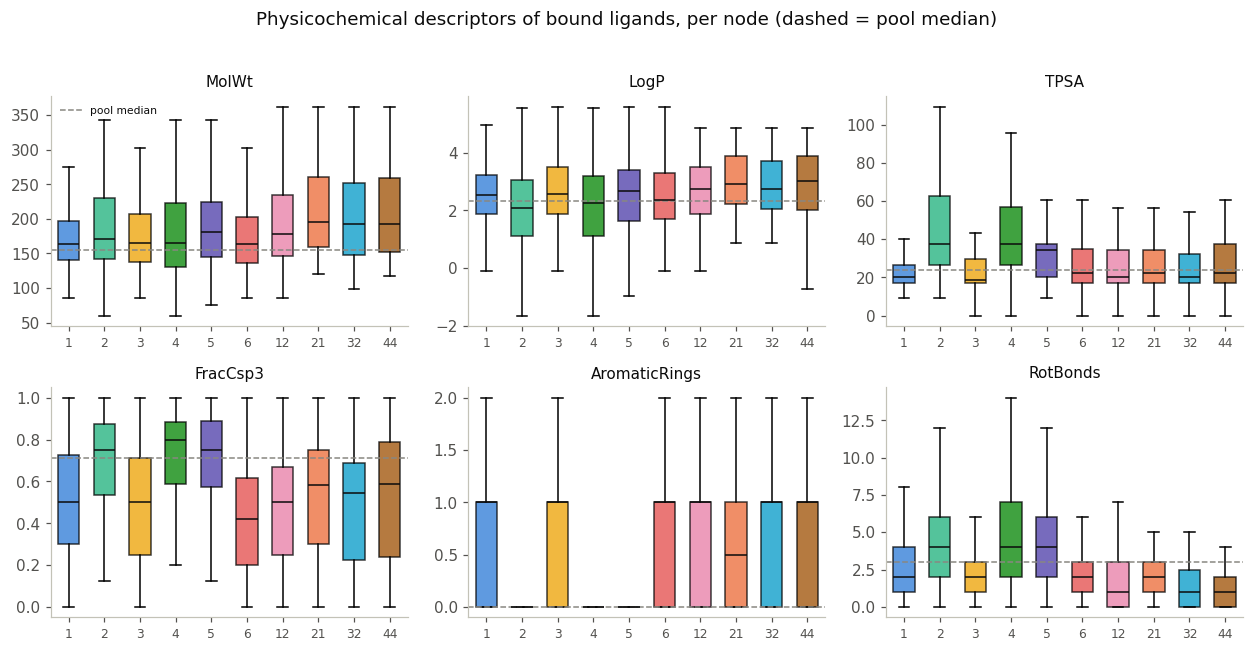

In [14]:
CONT = ["MolWt","LogP","TPSA","HBD","HBA","RotBonds","AromaticRings","RingCount","FracCsp3","HeavyAtoms"]
FGS  = [c for c in desc.columns if c.startswith("fg_")]
def chem_summary(smls, label):
    d = desc.reindex([s for s in smls if s in desc.index])
    row = {"set": label, "n": len(d)}
    for c in CONT: row[c] = round(float(d[c].median()), 3)
    for c in FGS:  row[c.replace("fg_","frac_")] = round(float(d[c].mean()), 3)
    return row
chem_rows = [chem_summary(POOL, "POOL(baseline)")]
for n in NODES: chem_rows.append(chem_summary(bound[n], f"node_{n}"))
for n in gain_sets:
    if gain_sets[n]: chem_rows.append(chem_summary(gain_sets[n], f"node_{n}_gain"))
for n in loss_sets:
    if loss_sets[n]: chem_rows.append(chem_summary(loss_sets[n], f"node_{n}_loss"))
chem = pd.DataFrame(chem_rows).set_index("set")
chem.to_csv(f"{RES}/chemistry_summary.csv")

# descriptor boxplots per node (key descriptors) vs pool baseline
key = ["MolWt","LogP","TPSA","FracCsp3","AromaticRings","RotBonds"]
fig, axes = plt.subplots(2, 3, figsize=(11.5, 6))
for ax, c in zip(axes.ravel(), key):
    data = [desc.reindex([s for s in bound[n] if s in desc.index])[c].dropna().values for n in NODES]
    bp = ax.boxplot(data, positions=range(len(NODES)), widths=0.6, patch_artist=True,
                    showfliers=False, medianprops=dict(color=INK))
    for patch, n in zip(bp["boxes"], NODES): patch.set_facecolor(NCOL[n]); patch.set_alpha(0.75)
    ax.axhline(desc.reindex(POOL)[c].median(), color=MUT, ls="--", lw=1, label="pool median")
    ax.set_xticks(range(len(NODES))); ax.set_xticklabels(NODES, fontsize=8)
    ax.set_title(c, fontsize=10)
axes.ravel()[0].legend(frameon=False, fontsize=7)
fig.suptitle("Physicochemical descriptors of bound ligands, per node (dashed = pool median)", fontsize=12)
fig.tight_layout(rect=[0,0,1,0.96]); savefig(fig, "fig8_chem_boxplots"); plt.show()

saved fig9_functional_groups


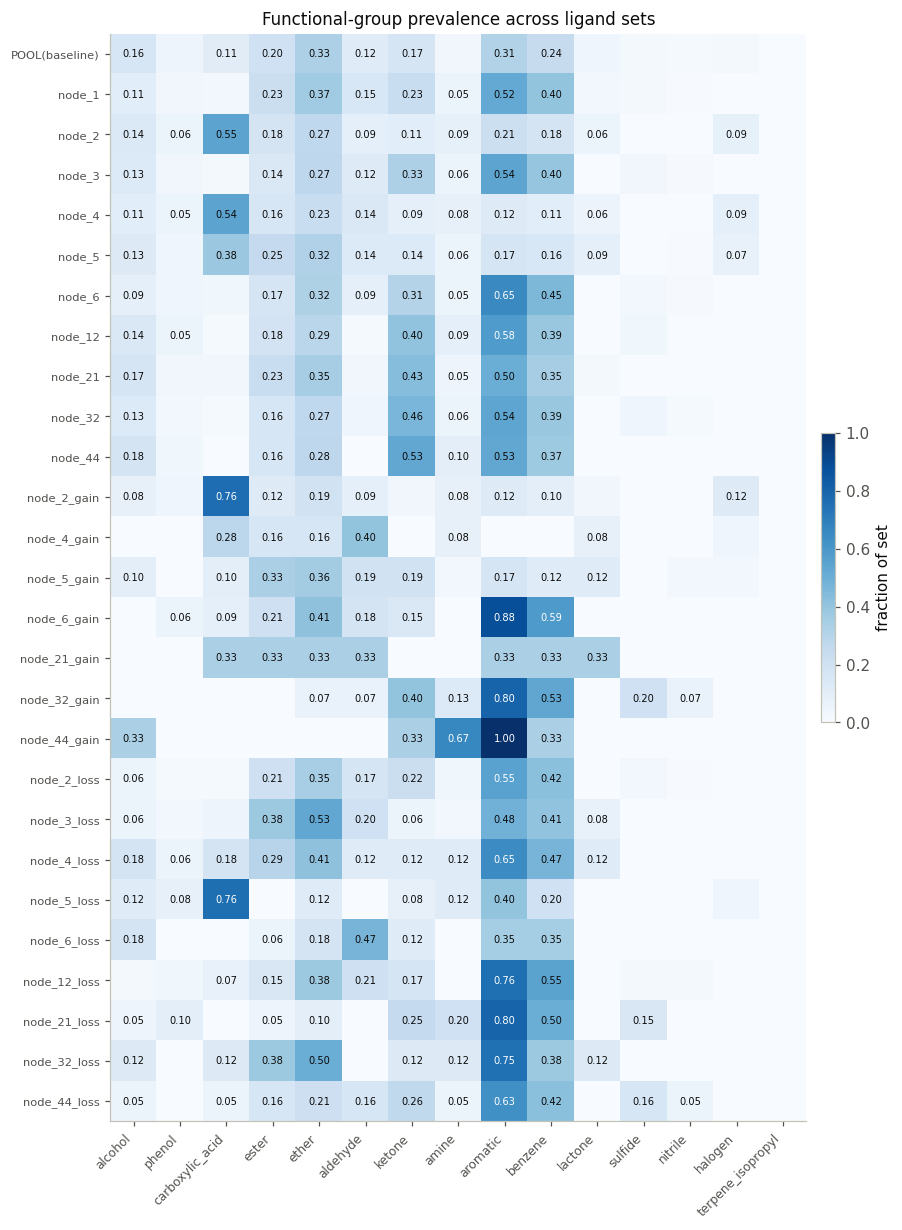

,n,MolWt,LogP,TPSA,HBD,HBA,RotBonds,AromaticRings,RingCount,FracCsp3,...,frac_aldehyde,frac_ketone,frac_amine,frac_aromatic,frac_benzene,frac_lactone,frac_sulfide,frac_nitrile,frac_halogen,frac_terpene_isopropyl
set,,,,,,,,,,,,,,,,,,,,,
POOL(baseline),754,154.253,2.338,23.79,0.0,1.0,3.0,0.0,1.0,0.714,...,0.121,0.171,0.033,0.309,0.243,0.042,0.020,0.012,0.020,0.0
node_1,177,164.204,2.550,20.23,0.0,2.0,2.0,1.0,1.0,0.500,...,0.153,0.232,0.051,0.520,0.401,0.028,0.023,0.006,0.000,0.0
node_2,130,170.274,2.086,37.30,1.0,2.0,4.0,0.0,0.0,0.750,...,0.092,0.108,0.085,0.215,0.177,0.062,0.000,0.000,0.085,0.0
node_3,113,165.236,2.580,18.46,0.0,1.0,2.0,1.0,1.0,0.500,...,0.124,0.327,0.062,0.540,0.398,0.000,0.035,0.009,0.000,0.0
node_4,138,165.603,2.274,37.30,1.0,1.5,4.0,0.0,0.0,0.800,...,0.145,0.087,0.080,0.123,0.109,0.058,0.000,0.000,0.087,0.0
node_5,147,181.029,2.671,34.14,0.0,2.0,4.0,0.0,0.0,0.750,...,0.136,0.136,0.061,0.170,0.156,0.088,0.000,0.007,0.075,0.0
node_6,130,164.204,2.361,22.12,0.0,2.0,2.0,1.0,1.0,0.423,...,0.092,0.308,0.054,0.654,0.454,0.000,0.031,0.008,0.000,0.0
node_12,77,178.231,2.737,20.23,0.0,2.0,1.0,1.0,1.0,0.500,...,0.013,0.403,0.091,0.584,0.390,0.000,0.039,0.000,0.000,0.0
node_21,60,194.724,2.918,22.12,0.0,2.0,2.0,0.5,1.0,0.583,...,0.033,0.433,0.050,0.500,0.350,0.017,0.000,0.000,0.000,0.0


In [15]:
# functional-group prevalence heatmap (per node + gain/loss)
fgtab = chem[[c for c in chem.columns if c.startswith("frac_")]]
fig, ax = plt.subplots(figsize=(min(13, 1 + 0.5*len(fgtab.columns)), 0.42*len(fgtab)+1.5))
im = ax.imshow(fgtab.values.astype(float), cmap="Blues", aspect="auto", vmin=0, vmax=1)
ax.set_xticks(range(len(fgtab.columns)))
ax.set_xticklabels([c.replace("frac_","") for c in fgtab.columns], rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(fgtab.index))); ax.set_yticklabels(fgtab.index, fontsize=7.5)
for i in range(len(fgtab.index)):
    for j in range(len(fgtab.columns)):
        v = fgtab.values[i, j]
        if v >= 0.05:
            ax.text(j, i, f"{v:.2f}", ha="center", va="center", fontsize=6.5,
                    color="white" if v > 0.55 else INK)
fig.colorbar(im, ax=ax, fraction=0.02, pad=0.02, label="fraction of set")
ax.set_title("Functional-group prevalence across ligand sets", fontsize=11)
savefig(fig, "fig9_functional_groups"); plt.show()
chem

## 8. Sequence motifs (scaffold QC) and pocket function-shift candidates

The ten ancestral sequences were aligned with MAFFT (L-INS-i; 318 columns). We map the
canonical OR signature motifs [Malnic et al., *PNAS* 2004; Zozulya et al., *Genome Biol.*
2001], flagged conserved vs. divergent per node:

| Region | Motif | Variants allowed |
|---|---|---|
| TM1 | **GN** | — |
| IC1 | **LHTPMY** | — |
| TM3/IC2 | **MAYDRYVAIC** (contains DRY) | MALDRYVAIC, MAFDRYVAIC |
| TM6/IC3 | **KAFSTCxSH** | KAFSTCASH, KAFSTCSSH |
| TM7 | **PMLNPFIY** (contains NPxxY) | — |

**Important framing.** These are the **intracellular / conserved-scaffold** signatures: they
are what makes a sequence recognisably an OR, and they are highly conserved precisely because
they contact G<sub>olf</sub> and the signalling machinery, **not the ligand**. If our
ancestral nodes all conserve them, that confirms the reconstructions are clean ORs but says
little about ligand specificity. We therefore treat motif conservation as a **QC / orientation
check**. The residues that actually explain a Class-I-like pocket and any gain/loss are the
**pocket-lining TM3 / TM5 / TM6 positions**, which are variable and lie *outside* these motifs.
Accordingly we (i) verify the scaffold is intact, then (ii) search the **variable, non-scaffold
columns flanking the anchors** for positions that separate the Class I clade (nodes 2/4/5) from
the Class II trunk and co-vary with the functional gains/losses — that is where the
neofunctionalization signal should be, if it is anywhere.

In [16]:
from Bio import AlignIO
aln = AlignIO.read(ALN8, "fasta")
al_ids = [r.id for r in aln]                          # node_1 ... node_44
order_idx = [al_ids.index(f"node_{n}") for n in NODES]
M = np.array([list(str(aln[i].seq)) for i in order_idx])   # 8 x L, rows in NODES order
L = M.shape[1]
# per-column conservation
cons_rows = []
for j in range(L):
    col = M[:, j]; res = [c for c in col if c != "-"]
    from collections import Counter
    cnt = Counter(col)
    top, topn = cnt.most_common(1)[0]
    non_gap = Counter(res)
    consensus = non_gap.most_common(1)[0][0] if non_gap else "-"
    frac = (col == consensus).sum() / NN
    cons_rows.append({"col": j, "consensus": consensus, "identity": frac,
                      "n_gap": int((col == "-").sum()),
                      "deviating_nodes": ";".join(str(NODES[k]) for k in range(NN)
                                                  if col[k] != consensus)})
cons = pd.DataFrame(cons_rows)
cons.to_csv(f"{RES}/motif_column_conservation.csv", index=False)
print("alignment:", M.shape, "| fully-conserved columns:", int((cons.identity==1).sum()),
      "| >=90% identity:", int((cons.identity>=0.9).sum()))

alignment: (10, 318) | fully-conserved columns: 80 | >=90% identity: 124


saved fig10_conservation_logo


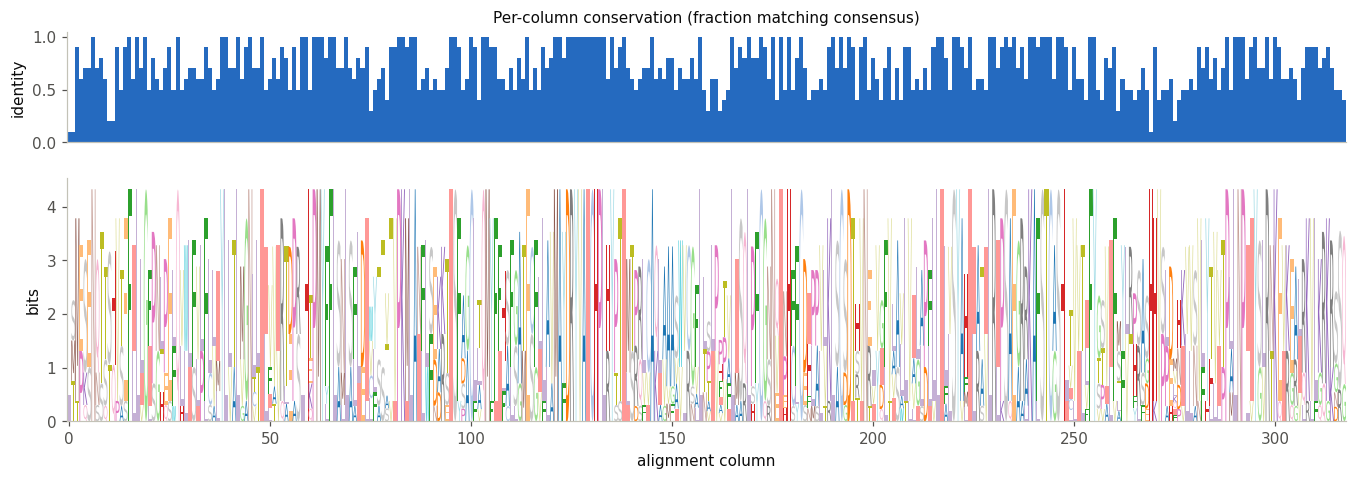

In [17]:
# conservation track + logo (information content, bits) over the alignment
AA = "ACDEFGHIKLMNPQRSTVWY"
def col_bits(col):
    res = [c for c in col if c != "-"]; N = len(res)
    if N == 0: return 0.0, {}
    from collections import Counter
    f = {a: c/N for a, c in Counter(res).items()}
    H = -sum(p*np.log2(p) for p in f.values() if p > 0)
    e = (1/np.log(2)) * (len(set(res))-1)/(2*N)        # small-sample correction (approx)
    R = max(0.0, np.log2(20) - (H + e))
    return R, {a: f[a]*R for a in f}
bits = [col_bits(M[:, j]) for j in range(L)]

try:
    from matplotlib.textpath import TextPath
    from matplotlib.patches import PathPatch
    from matplotlib.transforms import Affine2D
    HAVE_TP = True
except Exception:
    HAVE_TP = False
AAC = {a: c for a, c in zip(AA, plt.cm.tab20(np.linspace(0,1,20)))}

fig, (a1, a2) = plt.subplots(2, 1, figsize=(15, 4.6), gridspec_kw=dict(height_ratios=[1, 2.2]))
a1.bar(range(L), cons.identity.values, color="#256abf", width=1.0)
a1.set_ylabel("identity"); a1.set_xlim(-0.5, L-0.5); a1.set_title("Per-column conservation (fraction matching consensus)", fontsize=10)
a1.set_xticks([])
for j in range(L):
    R, heights = bits[j]
    y0 = 0
    for a, h in sorted(heights.items(), key=lambda kv: kv[1]):
        if h <= 0: continue
        if HAVE_TP:
            tp = TextPath((0, 0), a, size=1, prop=None)
            bb = tp.get_extents(); w = bb.width or 1; ht = bb.height or 1
            tr = Affine2D().translate(-bb.x0, -bb.y0).scale(1.0/w, h/ht).translate(j-0.4, y0)
            a2.add_patch(PathPatch(tr.transform_path(tp), color=AAC[a], lw=0))
        y0 += h
a2.set_ylim(0, max(0.1, max(b[0] for b in bits) * 1.05)); a2.set_xlim(-0.5, L-0.5)
a2.set_ylabel("bits"); a2.set_xlabel("alignment column")
savefig(fig, "fig10_conservation_logo"); plt.show()

In [18]:
# ---- map canonical OR signature motifs (Malnic 2004 PNAS; Zozulya 2001 Genome Biol) ----
consensus_seq = "".join(cons.consensus.tolist())
ungapped_cols = [j for j in range(L) if cons.consensus.iloc[j] != "-"]
def find_motif(full, core):
    for rgx in (full, core):
        m = re.search(rgx, consensus_seq.replace("-", ""))
        if m: return ungapped_cols[m.start()], ungapped_cols[m.end()-1], m.group(), (rgx is full)
    return None
# (name, full regex, robust core regex)
MOTIFS = [
    ("TM1 GN",             r"GN",                        r"GN"),
    ("IC1 LHTPMY",         r"L[HN]TP[ML]Y",              r"TP[ML]Y"),
    ("TM3/IC2 MAYDRYVAIC", r"MA[YLF]DRY[VITAS]A[ILVF]C", r"MA[YLF]DRY"),
    ("TM6/IC3 KAFSTCxSH",  r"KAFSTC[AS]SH",              r"FSTC[AS]SH"),
    ("TM7 PMLNPFIY",       r"PM[LMV]NP[FLIVM]IY",        r"NP[FLIVM]IY"),
]
mot_rows = []
for name, full, core in MOTIFS:
    hit = find_motif(full, core)
    if hit is None:
        mot_rows.append({"motif": name, "aln_cols": "not found", "consensus": "-",
                         "conserved_all_nodes": False, "n_nodes_match_canonical": 0, "per_node": "-"})
        continue
    c0, c1, sub, was_full = hit
    rgx_used = full if was_full else core          # count matches to the regex that actually located it
    block = M[:, c0:c1+1]
    persite = [f"node_{n}:" + "".join(block[k]) for k, n in enumerate(NODES)]
    conserved = all((block[:, jj] == block[0, jj]).all() for jj in range(block.shape[1]))
    nmatch = sum(bool(re.search(rgx_used, "".join(block[k]))) for k in range(NN))
    mot_rows.append({"motif": name, "aln_cols": f"{c0}-{c1}", "consensus": sub,
                     "matched_full_motif": bool(was_full),
                     "conserved_all_nodes": conserved, "n_nodes_match_canonical": nmatch,
                     "per_node": " | ".join(persite)})
motif_tab = pd.DataFrame(mot_rows)
motif_tab.to_csv(f"{RES}/motif_map_canonical.csv", index=False)
# QC verdict: scaffold is intact if every motif is present in all nodes (allowing tolerated variants)
qc_ok = all(r["aln_cols"] != "not found" for r in mot_rows)
print("SCAFFOLD QC:", "PASS — all canonical OR motifs present (clean ORs)" if qc_ok else "CHECK — a motif missing")
for r in mot_rows:
    print(f"  {r['motif']:<20} cols {r['aln_cols']:<9} consensus {r['consensus']:<11}"
          f" nodes-matching-canonical {r['n_nodes_match_canonical']}/{NN}")
motif_tab[["motif","aln_cols","consensus","conserved_all_nodes","n_nodes_match_canonical"]]

SCAFFOLD QC: PASS — all canonical OR motifs present (clean ORs)
  TM1 GN               cols 44-45     consensus GN          nodes-matching-canonical 9/10
  IC1 LHTPMY           cols 58-63     consensus LHTPMY      nodes-matching-canonical 5/10
  TM3/IC2 MAYDRYVAIC   cols 121-130   consensus MAYDRYVAIC  nodes-matching-canonical 10/10
  TM6/IC3 KAFSTCxSH    cols 239-247   consensus KAFSTCASH   nodes-matching-canonical 6/10
  TM7 PMLNPFIY         cols 291-295   consensus NPIIY       nodes-matching-canonical 9/10


,motif,aln_cols,consensus,conserved_all_nodes,n_nodes_match_canonical
0,TM1 GN,44-45,GN,False,9
1,IC1 LHTPMY,58-63,LHTPMY,False,5
2,TM3/IC2 MAYDRYVAIC,121-130,MAYDRYVAIC,False,10
3,TM6/IC3 KAFSTCxSH,239-247,KAFSTCASH,False,6
4,TM7 PMLNPFIY,291-295,NPIIY,False,9


In [19]:
# ---- pocket function-shift candidates (variable, NON-scaffold columns) ----
# The scaffold motifs are excluded: specificity lives in the variable TM3/TM5/TM6 pocket
# columns FLANKING the anchors. We prioritise columns that (a) cleanly separate the Class I
# clade from the Class II trunk and/or (b) flip in exactly the node(s) with large gains/losses.
scaffold_cols = set()
anchor = {}
for _, r in motif_tab.iterrows():
    if isinstance(r.aln_cols, str) and "-" in r.aln_cols:
        a, b = map(int, r.aln_cols.split("-")); scaffold_cols |= set(range(a, b + 1))
        anchor[r.motif] = (a, b)
# approximate pocket windows (extracellular half of each TM, relative to its intracellular anchor)
maydry0 = anchor.get("TM3/IC2 MAYDRYVAIC", (120, 129))[0]
kafstc1 = anchor.get("TM6/IC3 KAFSTCxSH", (239, 247))[1]
npxxy0  = anchor.get("TM7 PMLNPFIY", (289, 296))[0]
def region(j):
    if maydry0 - 38 <= j < maydry0:            return "TM3-pocket"
    if kafstc1 < j <= kafstc1 + 32:            return "TM6-pocket"
    if maydry0 + 12 <= j <= kafstc1 - 20:      return "TM4/TM5-region"
    if npxxy0 - 22 <= j < npxxy0:              return "TM7-pocket"
    return "other"

gl_mag = {n: (len(gain_sets.get(n, [])) + len(loss_sets.get(n, []))) for n in NODES}
CI, CII = CLASS_I_NODES, CLASS_II_NODES
rows = []
for j in range(L):
    if j in scaffold_cols or cons.identity.iloc[j] == 1: continue
    colr = {n: M[NODES.index(n), j] for n in NODES}
    if "-" in colr.values(): continue
    ci_res  = set(colr[n] for n in CI); cii_res = set(colr[n] for n in CII)
    class_disc = (len(ci_res) == 1 and len(cii_res) == 1 and ci_res != cii_res)
    dev = [n for n in NODES if colr[n] != cons.consensus.iloc[j]]
    rows.append({"col": j, "region": region(j), "consensus": cons.consensus.iloc[j],
                 "identity": cons.identity.iloc[j],
                 "class_I_res": "".join(sorted(ci_res)), "class_II_res": "".join(sorted(cii_res)),
                 "class_I_discriminating": class_disc,
                 "deviating_nodes": ";".join(map(str, dev)),
                 "gl_mag_of_deviating": sum(gl_mag.get(d, 0) for d in dev)})
cand = pd.DataFrame(rows)
cand["pocket"] = cand.region.isin(["TM3-pocket","TM4/TM5-region","TM6-pocket","TM7-pocket"])
cand = cand.sort_values(["class_I_discriminating","pocket","gl_mag_of_deviating"],
                        ascending=[False, False, False])
cand.to_csv(f"{RES}/candidate_function_shifting_positions.csv", index=False)
nCI = int(cand.class_I_discriminating.sum())
print(f"variable non-scaffold columns examined: {len(cand)} | Class-I-discriminating: {nCI}"
      f" | of those in a pocket window: {int((cand.class_I_discriminating & cand.pocket).sum())}")
print("\nTop Class-I-discriminating pocket candidates (Class I res -> Class II res):")
top = cand[cand.class_I_discriminating & cand.pocket].head(15)
for _, r in top.iterrows():
    print(f"  col {r.col:>3} [{r.region:<14}] {r.class_I_res} (I) vs {r.class_II_res} (II)")
cand.head(20)

variable non-scaffold columns examined: 222 | Class-I-discriminating: 39 | of those in a pocket window: 23

Top Class-I-discriminating pocket candidates (Class I res -> Class II res):
  col  89 [TM3-pocket    ] W (I) vs L (II)
  col  99 [TM3-pocket    ] A (I) vs G (II)
  col 107 [TM3-pocket    ] I (I) vs F (II)
  col 113 [TM3-pocket    ] M (I) vs T (II)
  col 116 [TM3-pocket    ] G (I) vs F (II)
  col 119 [TM3-pocket    ] L (I) vs A (II)
  col 134 [TM4/TM5-region] R (I) vs H (II)
  col 146 [TM4/TM5-region] K (I) vs Q (II)
  col 152 [TM4/TM5-region] V (I) vs W (II)
  col 154 [TM4/TM5-region] R (I) vs C (II)
  col 160 [TM4/TM5-region] I (I) vs L (II)
  col 191 [TM4/TM5-region] A (I) vs S (II)
  col 201 [TM4/TM5-region] Y (I) vs V (II)
  col 203 [TM4/TM5-region] L (I) vs F (II)
  col 213 [TM4/TM5-region] D (I) vs P (II)


,col,region,consensus,identity,class_I_res,class_II_res,class_I_discriminating,deviating_nodes,gl_mag_of_deviating,pocket
61,89,TM3-pocket,L,0.7,W,L,True,2;4;5,334,True
69,99,TM3-pocket,G,0.6,A,G,True,1;2;4;5,334,True
74,107,TM3-pocket,F,0.6,I,F,True,1;2;4;5,334,True
80,113,TM3-pocket,T,0.6,M,T,True,1;2;4;5,334,True
82,116,TM3-pocket,F,0.7,G,F,True,2;4;5,334,True
85,119,TM3-pocket,A,0.7,L,A,True,2;4;5,334,True
87,134,TM4/TM5-region,H,0.6,R,H,True,1;2;4;5,334,True
96,146,TM4/TM5-region,Q,0.6,K,Q,True,1;2;4;5,334,True
102,152,TM4/TM5-region,W,0.7,V,W,True,2;4;5,334,True
104,154,TM4/TM5-region,C,0.6,R,C,True,1;2;4;5,334,True


saved fig11_pocket_vs_scaffold


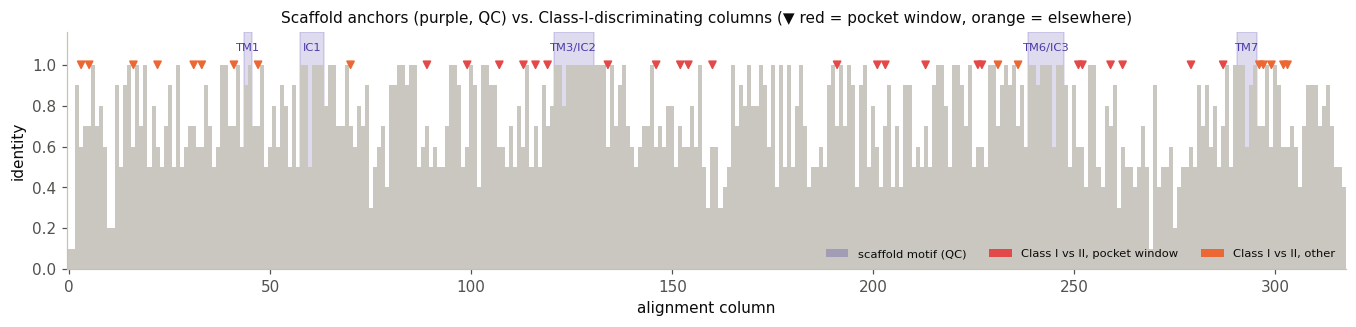

In [20]:
# figure: conservation track with scaffold anchors (grey) + Class-I-discriminating pocket columns (red)
fig, ax = plt.subplots(figsize=(15, 2.8))
ax.bar(range(L), cons.identity.values, color="#c9c7bf", width=1.0, zorder=1)
for name, (a, b) in anchor.items():
    ax.axvspan(a-0.5, b+0.5, color="#4a3aa7", alpha=0.18, zorder=0)
    ax.text((a+b)/2, 1.06, name.split()[0], ha="center", va="bottom", fontsize=7.5, color="#4a3aa7")
disc = cand[cand.class_I_discriminating]
ax.scatter(disc.col, [1.0]*len(disc), marker="v", s=22,
           color=["#e34948" if p else "#eb6834" for p in disc.pocket], zorder=3)
ax.set_xlim(-0.5, L-0.5); ax.set_ylim(0, 1.16); ax.set_ylabel("identity")
ax.set_xlabel("alignment column")
ax.set_title("Scaffold anchors (purple, QC) vs. Class-I-discriminating columns "
             "(▼ red = pocket window, orange = elsewhere)", fontsize=10)
from matplotlib.patches import Patch as _P
ax.legend(handles=[_P(facecolor="#4a3aa7", alpha=0.3, label="scaffold motif (QC)"),
                   _P(facecolor="#e34948", label="Class I vs II, pocket window"),
                   _P(facecolor="#eb6834", label="Class I vs II, other")],
          frameon=False, fontsize=7.5, loc="lower right", ncol=3)
savefig(fig, "fig11_pocket_vs_scaffold"); plt.show()

## Deliverables

All written to `Results_july9/` (tables) and `Results_july9/figures/` (png + svg):

**Topology** — `topology_summary.csv`, `pairwise_mrca.csv`, `induced_subtree_edges.csv`,
`fig2_induced_subtree`. **Repertoires** — `repertoires_per_node.csv`,
`fig3_repertoire_sizes`. **Overlap** — `strict_intersection_ligands.csv`,
`pairwise_intersection_size.csv`, `pairwise_jaccard.csv`, `upset_intersections.csv`,
`fig4_overlap_matrices`, `fig5_upset`. **Gains/losses** — `edge_gain_loss_summary.csv`,
`edge_gain_loss_ligands.csv`, `ordered_pair_differences.csv`,
`ordered_pair_A_only_ligands.csv`, `fig6_gain_loss`. **Enrichment** —
`enrichment_per_node.csv`, `enrichment_gain_loss.csv`, `fig7_enrichment_per_node_union10`.
**Chemistry** — `chemistry_summary.csv`, `fig8_chem_boxplots`, `fig9_functional_groups`.
**OR class** — `topology_summary.csv` (OR_class, frac_class_I_descendants), `fig2b_node_or_class`.
**Motifs/pocket** — `motif_column_conservation.csv`, `motif_map_canonical.csv`,
`candidate_function_shifting_positions.csv` (Class-I-discriminating, region-annotated),
`fig10_conservation_logo`, `fig11_pocket_vs_scaffold`.